In [ ]:
import pandas as pd

# Bài 1: Khởi tạo Toy Dataset dựa trên nội dung PDF
data = {
    'Công ty': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'Doanh thu (Tỷ VNĐ)': [3, 6, 9, 10, 12, 15, 18, 20, 25, 8, 14, 22],
    'Lợi nhuận (Tỷ VNĐ)': [1.1, 2.0, 3.2, 3.4, 3.9, 5.0, 6.2, 6.6, 8.2, 2.5, 4.5, 7.5],
    'Chi phí Marketing (Tỷ VNĐ)': [0.5, 0.8, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0, 3.5, 1.0, 1.9, 3.2],
    'Số lượng khách hàng': [320, 450, 700, 750, 850, 1100, 1350, 1500, 1800, 600, 1000, 1650],
    'Đánh giá hiệu suất (Label)': ['Kém', 'Kém', 'Bình thường', 'Bình thường', 'Bình thường', 'Tốt', 'Tốt', 'Tốt', 'Xuất sắc', 'Kém', 'Bình thường', 'Xuất sắc']
}

df = pd.DataFrame(data)
print('--- Toy Dataset (Bài 1) ---')
display(df)

--- Toy Dataset (Bài 1) ---


,Công ty,Doanh thu (Tỷ VNĐ),Lợi nhuận (Tỷ VNĐ),Chi phí Marketing (Tỷ VNĐ),Số lượng khách hàng,Đánh giá hiệu suất (Label)
0,1,3,1.1,0.5,320,Kém
1,2,6,2.0,0.8,450,Kém
2,3,9,3.2,1.2,700,Bình thường
3,4,10,3.4,1.5,750,Bình thường
4,5,12,3.9,1.8,850,Bình thường
5,6,15,5.0,2.0,1100,Tốt
6,7,18,6.2,2.5,1350,Tốt
7,8,20,6.6,3.0,1500,Tốt
8,9,25,8.2,3.5,1800,Xuất sắc
9,10,8,2.5,1.0,600,Kém


# Mục mới

BÀI 2

bài toán phân loại2 lớp


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# --- Bước 2a: Tiền xử lý dữ liệu (Phân loại 2 lớp) ---

# 1. Dán nhãn lại cho bài toán nhị phân
# Quy tắc: {Kém, Bình thường} -> 0 | {Tốt, Xuất sắc} -> 1
binary_mapping = {
    'Kém': 0,
    'Bình thường': 0,
    'Tốt': 1,
    'Xuất sắc': 1
}
y_binary = df['Đánh giá hiệu suất (Label)'].map(binary_mapping)

# 2. Trích xuất đặc trưng (X)
X = df[['Doanh thu (Tỷ VNĐ)', 'Lợi nhuận (Tỷ VNĐ)', 'Chi phí Marketing (Tỷ VNĐ)', 'Số lượng khách hàng']]

# 3. Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# 4. Chia tập dữ liệu thành Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)

print('--- Kết quả bước 2a: Tiền xử lý (2 lớp) ---')
display(X_scaled_df.head())
print(f'\nSố mẫu tập Huấn luyện: {len(X_train)}')
print(f'Số mẫu tập Kiểm tra: {len(X_test)}')
print('Mã hóa nhãn: {0: "Kém/Bình thường", 1: "Tốt/Xuất sắc"}')

--- Kết quả bước 2a: Tiền xử lý (2 lớp) ---


,Doanh thu (Tỷ VNĐ),Lợi nhuận (Tỷ VNĐ),Chi phí Marketing (Tỷ VNĐ),Số lượng khách hàng
0,-1.625029,-1.587575,-1.507787,-1.489391
1,-1.160735,-1.168362,-1.186602,-1.207076
2,-0.696441,-0.609411,-0.758354,-0.664163
3,-0.541676,-0.516253,-0.437169,-0.555581
4,-0.232147,-0.283357,-0.115984,-0.338416



Số mẫu tập Huấn luyện: 9
Số mẫu tập Kiểm tra: 3
Mã hóa nhãn: {0: "Kém/Bình thường", 1: "Tốt/Xuất sắc"}


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Khởi tạo danh sách để lưu kết quả
results = []

# Duyệt qua từng mô hình đã huấn luyện trong biến 'models'
for name, model in models.items():
    # Dự báo trên tập huấn luyện và tập kiểm tra
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Tính toán các chỉ số trên tập kiểm tra
    accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Hiển thị bảng so sánh kết quả
df_results = pd.DataFrame(results)
print('--- Kết quả đánh giá mô hình trên tập Test (2 lớp) ---')
display(df_results)

--- Kết quả đánh giá mô hình trên tập Test (2 lớp) ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,1.000000,1.0,1.000000,1.0
1,KNN,1.000000,1.0,1.000000,1.0
2,SVM,1.000000,1.0,1.000000,1.0
3,Random Forest,0.666667,1.0,0.666667,0.8


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 1. Khởi tạo các mô hình
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'SVM': SVC(probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# 2. Huấn luyện các mô hình trên tập dữ liệu 2 lớp (Binary)
print('--- Đang huấn luyện các mô hình (2 lớp) ---')
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'Đã huấn luyện xong: {name}')

print('\nTất cả mô hình đã sẵn sàng để đánh giá.')

--- Đang huấn luyện các mô hình (2 lớp) ---
Đã huấn luyện xong: Logistic Regression
Đã huấn luyện xong: KNN
Đã huấn luyện xong: SVM
Đã huấn luyện xong: Random Forest

Tất cả mô hình đã sẵn sàng để đánh giá.


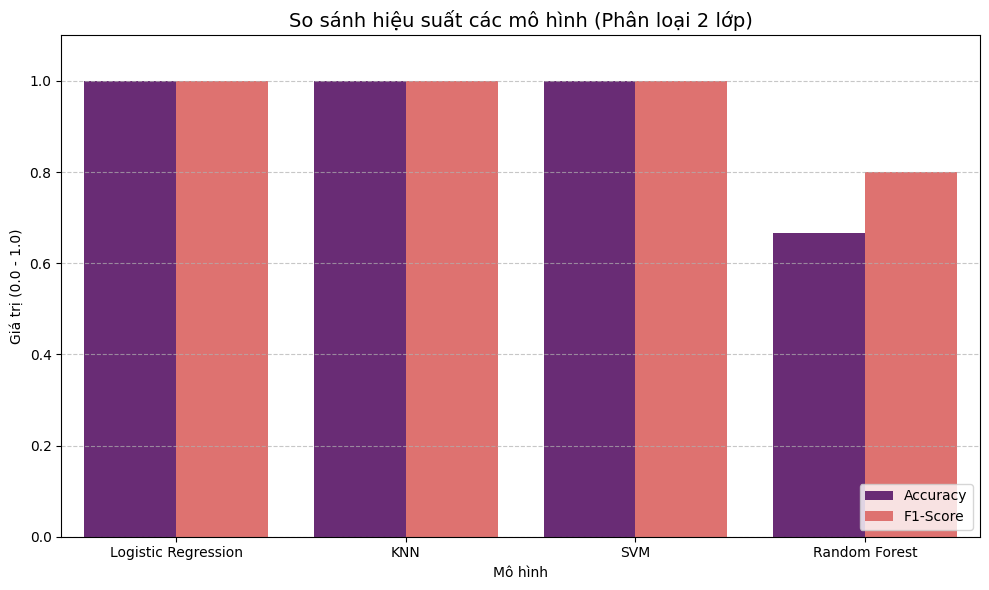

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(10, 6))

# Chuyển dữ liệu sang dạng long-format để vẽ biểu đồ nhóm bằng seaborn
df_plot = df_results.melt(id_vars='Model', value_vars=['Accuracy', 'F1-Score'], var_name='Metric', value_name='Score')

# Vẽ biểu đồ cột
sns.barplot(data=df_plot, x='Model', y='Score', hue='Metric', palette='magma')

# Thêm tiêu đề và nhãn
plt.title('So sánh hiệu suất các mô hình (Phân loại 2 lớp)', fontsize=14)
plt.ylim(0, 1.1)
plt.ylabel('Giá trị (0.0 - 1.0)')
plt.xlabel('Mô hình')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

### Phân tích mô hình tốt nhất (2 lớp)

Dựa trên bảng kết quả và biểu đồ:
- **Logistic Regression, KNN, SVM**: Đều đạt **Accuracy: 1.0** và **F1-Score: 1.0**.
- **Random Forest**: Đạt hiệu suất thấp hơn một chút (Accuracy ~0.67).

**Kết luận:** Với tập dữ liệu Toy Dataset hiện tại, các mô hình như **Logistic Regression** hoặc **SVM** là lựa chọn tốt nhất vì chúng đơn giản và đạt hiệu quả tối đa. Lưu ý rằng vì tập kiểm tra rất nhỏ (3 mẫu), kết quả 100% có thể chưa phản ánh hoàn toàn thực tế nếu dữ liệu lớn hơn.

# PHÂN LOẠI ĐA LỚP

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# --- Bước 2b: Tiền xử lý dữ liệu (Phân loại Đa lớp - 4 nhãn) ---

# 1. Định nghĩa ánh xạ cho 4 nhãn
multiclass_mapping = {
    'Kém': 0,
    'Bình thường': 1,
    'Tốt': 2,
    'Xuất sắc': 3
}

# 2. Tạo nhãn y cho bài toán đa lớp
y_multiclass = df['Đánh giá hiệu suất (Label)'].map(multiclass_mapping)

# 3. Trích xuất đặc trưng (X)
X_multi = df[['Doanh thu (Tỷ VNĐ)', 'Lợi nhuận (Tỷ VNĐ)', 'Chi phí Marketing (Tỷ VNĐ)', 'Số lượng khách hàng']]

# 4. Chuẩn hóa dữ liệu
scaler_multi = StandardScaler()
X_multi_scaled = scaler_multi.fit_transform(X_multi)

# 5. Chia tập dữ liệu thành Train (80%) và Test (20%)
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi_scaled, y_multiclass, test_size=0.2, random_state=42
)

print('--- Kết quả bước 2b: Tiền xử lý (Đa lớp) ---')
print(f'Mã hóa nhãn: {multiclass_mapping}')
print(f'Số mẫu tập Huấn luyện: {len(X_train_multi)}')
print(f'Số mẫu tập Kiểm tra: {len(X_test_multi)}')
display(pd.DataFrame(X_multi_scaled, columns=X_multi.columns).head())

--- Kết quả bước 2b: Tiền xử lý (Đa lớp) ---
Mã hóa nhãn: {'Kém': 0, 'Bình thường': 1, 'Tốt': 2, 'Xuất sắc': 3}
Số mẫu tập Huấn luyện: 9
Số mẫu tập Kiểm tra: 3


,Doanh thu (Tỷ VNĐ),Lợi nhuận (Tỷ VNĐ),Chi phí Marketing (Tỷ VNĐ),Số lượng khách hàng
0,-1.625029,-1.587575,-1.507787,-1.489391
1,-1.160735,-1.168362,-1.186602,-1.207076
2,-0.696441,-0.609411,-0.758354,-0.664163
3,-0.541676,-0.516253,-0.437169,-0.555581
4,-0.232147,-0.283357,-0.115984,-0.338416


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Khởi tạo danh sách để lưu kết quả
results = []

# Duyệt qua từng mô hình đã huấn luyện trong biến 'models'
for name, model in models.items():
    # Dự báo trên tập huấn luyện và tập kiểm tra
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Tính toán các chỉ số trên tập kiểm tra
    accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Hiển thị bảng so sánh kết quả
df_results = pd.DataFrame(results)
print('--- Kết quả đánh giá mô hình trên tập Test ---')
display(df_results)

--- Kết quả đánh giá mô hình trên tập Test ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.333333,0.111111,0.333333,0.166667
1,Random Forest,0.666667,0.833333,0.666667,0.666667
2,KNN,0.333333,0.111111,0.333333,0.166667
3,SVM,0.333333,0.111111,0.333333,0.166667


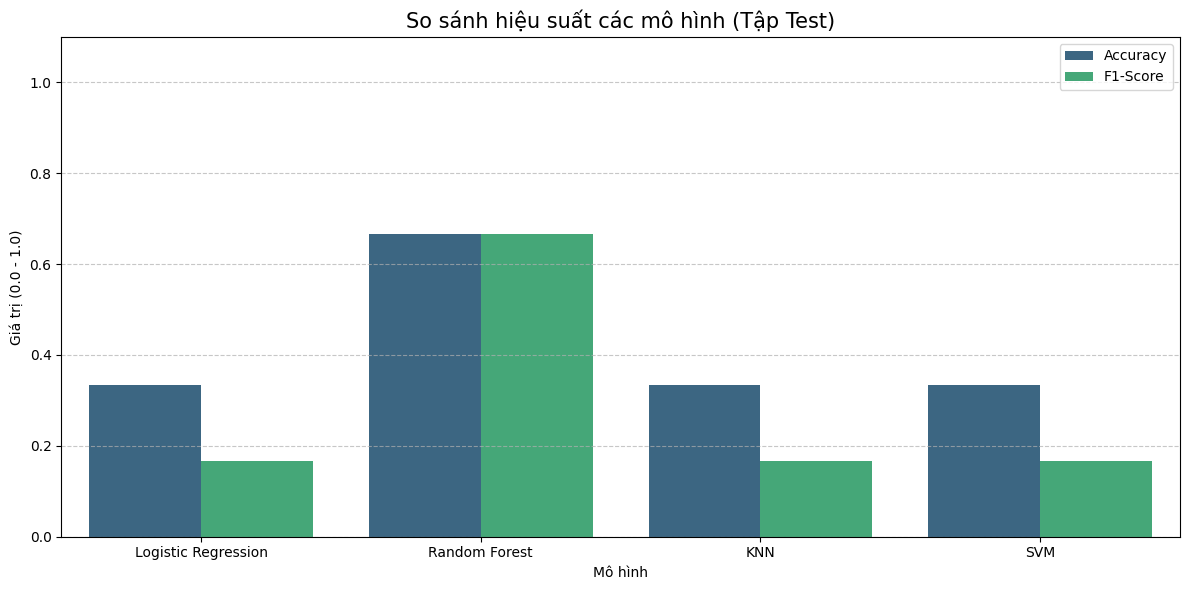

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập kích thước biểu đồ
plt.figure(figsize=(12, 6))

# Chuyển dữ liệu sang dạng long-format để vẽ biểu đồ nhóm bằng seaborn
df_plot = df_results.melt(id_vars='Model', value_vars=['Accuracy', 'F1-Score'], var_name='Metric', value_name='Score')

# Vẽ biểu đồ cột
sns.barplot(data=df_plot, x='Model', y='Score', hue='Metric', palette='viridis')

# Thêm tiêu đề và nhãn
plt.title('So sánh hiệu suất các mô hình (Tập Test)', fontsize=15)
plt.ylim(0, 1.1)  # Giới hạn trục y từ 0 đến 1
plt.ylabel('Giá trị (0.0 - 1.0)')
plt.xlabel('Mô hình')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

Mô hình tốt nhất: Random Forest

Đạt Accuracy (Độ chính xác) cao nhất (0.67) và F1-Score (0.67).
Lý do: Random Forest là một thuật toán mạnh mẽ với các tập dữ liệu nhỏ và có khả năng xử lý tốt các mối quan hệ phi tuyến tính giữa các đặc trưng (Doanh thu, Lợi nhuận, Khách hàng).
Các mô hình còn lại (Logistic Regression, KNN, SVM)

Cả ba mô hình này đều có kết quả thấp hơn hẳn với Accuracy chỉ đạt 0.33.
Logistic Regression: Thường gặp khó khăn khi dữ liệu không phân tách tuyến tính rõ ràng (đặc biệt là với 4 nhãn phân loại).
KNN & SVM: Với tập dữ liệu cực nhỏ (chỉ 12 mẫu tổng cộng, 9 mẫu training), các thuật toán này rất dễ bị nhiễu hoặc không có đủ dữ liệu để tìm ra ranh giới phân lớp tối ưu.
Kết luận: Với bài toán đánh giá hiệu suất công ty dựa trên Toy Dataset này, Random Forest là lựa chọn hiệu quả nhất. Tuy nhiên, vì dữ liệu quá ít (chỉ 3 mẫu kiểm tra), kết quả này mang tính chất tham khảo để hiểu quy trình làm việc hơn là khẳng định độ tin cậy tuyệt đối của mô hình.



### BÀI 3: HỌC KHÔNG GIÁM SÁT (CLUSTERING - K-MEANS)

### BÀI 3a: Xác định số cụm tối ưu (Elbow Method)

Chúng ta sẽ sử dụng phương pháp 'Cái khuỷu tay' (Elbow Method) để tìm giá trị $k$ phù hợp nhất cho thuật toán K-Means.
- **WCSS (Within-Cluster Sum of Squares):** Tổng bình phương khoảng cách từ các điểm đến tâm cụm của chúng.
- **Mục tiêu:** Tìm điểm mà tại đó việc tăng thêm số cụm không làm giảm đáng kể giá trị WCSS (điểm gãy/khuỷu tay).

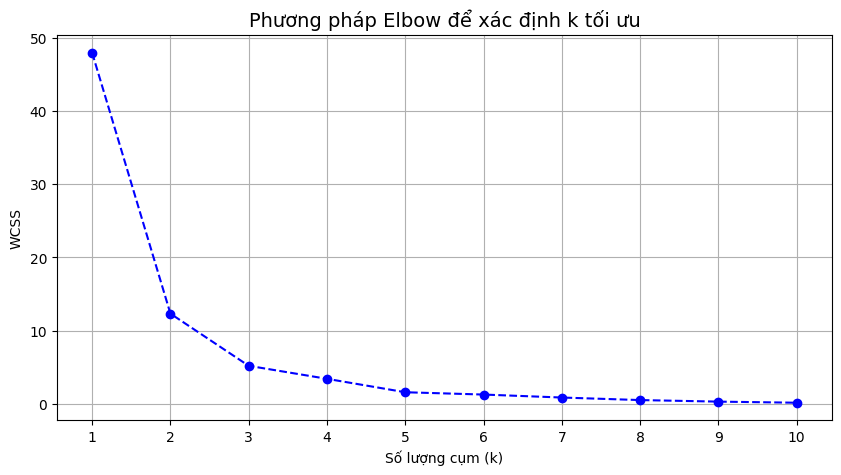

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Khởi tạo danh sách lưu giá trị WCSS
wcss = []

# 2. Chạy K-means với số lượng cụm từ 1 đến 10
# Lưu ý: X_scaled đã được chuẩn hóa từ Bài 2
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 3. Vẽ biểu đồ Elbow
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Phương pháp Elbow để xác định k tối ưu', fontsize=14)
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
# 2. Thực hiện phân cụm với k=3 (dựa trên điểm gãy của biểu đồ Elbow)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Thêm thông tin cụm vào DataFrame
df_clustered = df.copy()
df_clustered['Cluster'] = clusters

print('--- Kết quả phân cụm chi tiết ---')
display(df_clustered[['Công ty', 'Doanh thu (Tỷ VNĐ)', 'Lợi nhuận (Tỷ VNĐ)', 'Số lượng khách hàng', 'Cluster']])

--- Kết quả phân cụm chi tiết ---


,Công ty,Doanh thu (Tỷ VNĐ),Lợi nhuận (Tỷ VNĐ),Số lượng khách hàng,Cluster
0,1,3,1.1,320,2
1,2,6,2.0,450,2
2,3,9,3.2,700,2
3,4,10,3.4,750,0
4,5,12,3.9,850,0
5,6,15,5.0,1100,0
6,7,18,6.2,1350,1
7,8,20,6.6,1500,1
8,9,25,8.2,1800,1
9,10,8,2.5,600,2


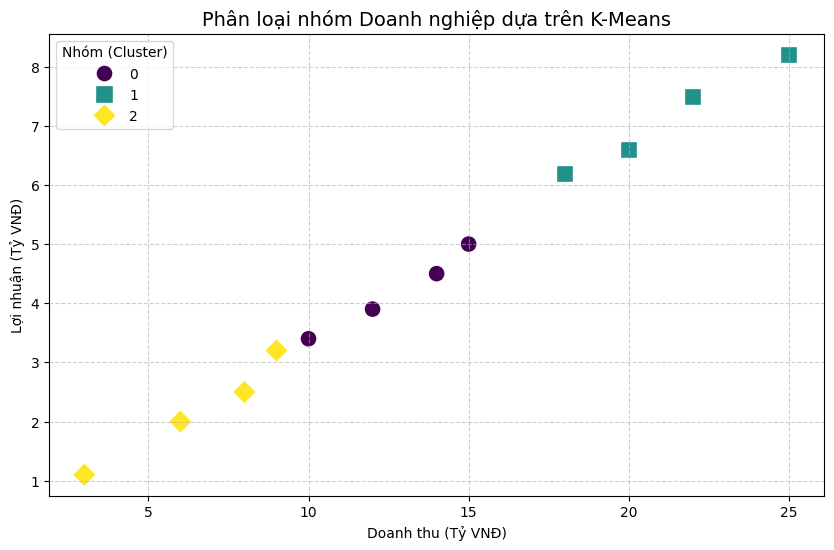

In [ ]:
# 3. Trực quan hóa kết quả phân cụm
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clustered, x='Doanh thu (Tỷ VNĐ)', y='Lợi nhuận (Tỷ VNĐ)',
                hue='Cluster', palette='viridis', s=150, style='Cluster', markers=['o', 's', 'D'])

plt.title('Phân loại nhóm Doanh nghiệp dựa trên K-Means', fontsize=14)
plt.xlabel('Doanh thu (Tỷ VNĐ)')
plt.ylabel('Lợi nhuận (Tỷ VNĐ)')
plt.legend(title='Nhóm (Cluster)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### BÀI 3b: Phân cụm phân cấp (Hierarchical Clustering) - Dendrogram

Biểu đồ Dendrogram giúp chúng ta quan sát cấu trúc phân cấp và quyết định số lượng cụm dựa trên khoảng cách giữa các nhóm dữ liệu.

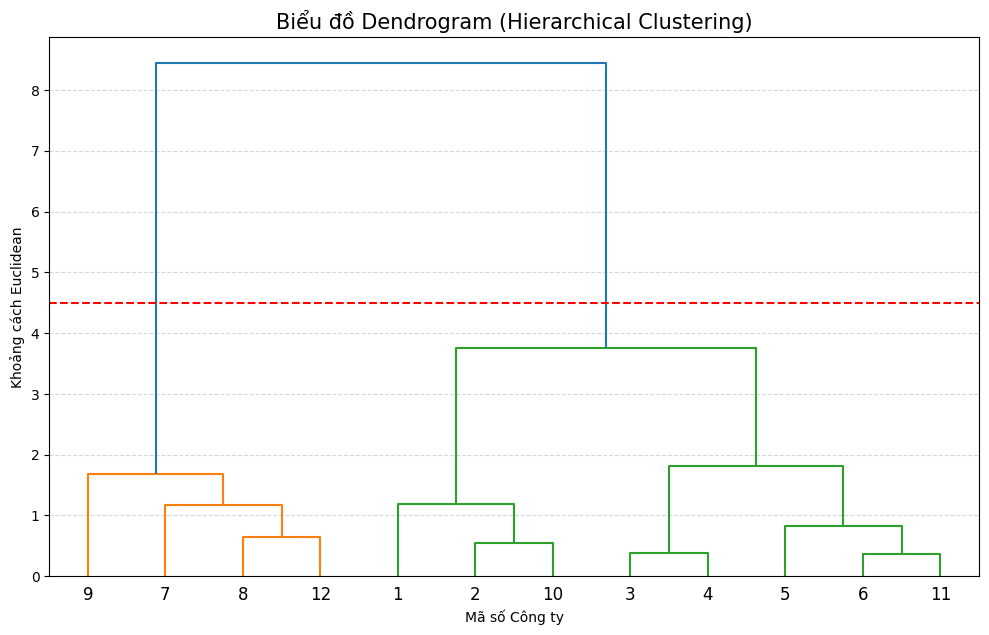

In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# 1. Tạo liên kết (linkage) giữa các điểm dữ liệu bằng phương pháp Ward
# Ward's method giúp tối thiểu hóa phương sai trong các cụm
plt.figure(figsize=(12, 7))
linkage_matrix = sch.linkage(X_scaled, method='ward')

# 2. Vẽ biểu đồ Dendrogram
dendrogram = sch.dendrogram(linkage_matrix, labels=df['Công ty'].values)

# 3. Thêm các thông tin bổ sung
plt.title('Biểu đồ Dendrogram (Hierarchical Clustering)', fontsize=15)
plt.xlabel('Mã số Công ty')
plt.ylabel('Khoảng cách Euclidean')
plt.axhline(y=4.5, color='r', linestyle='--') # Đường cắt giả định để chọn k=3
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### BÀI 3c: Thuật toán DBSCAN (Density-Based Spatial Clustering)

**Tại sao DBSCAN có thể không tốt với dataset này?**
1. **Kích thước dữ liệu quá nhỏ:** DBSCAN dựa trên mật độ. Với 12 mẫu, rất khó để định nghĩa một khu vực là 'dày đặc'.
2. **Độ nhạy tham số:** Trong không gian 4 chiều (sau khi chuẩn hóa), khoảng cách giữa các điểm có thể lớn, khiến việc chọn `eps` trở nên cực kỳ nhạy cảm.
3. **Hiện tượng Noise:** DBSCAN dễ dàng coi các công ty là 'nhiễu' (noise) nếu chúng không nằm gần ít nhất `min_samples` công ty khác.

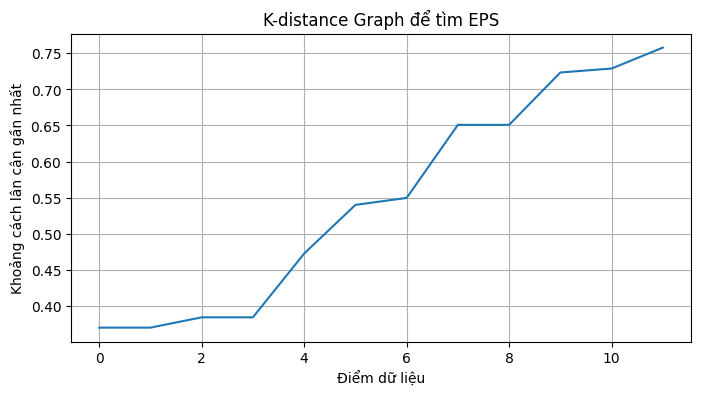

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np
from sklearn.neighbors import NearestNeighbors

# 1. Tìm EPS tối ưu bằng phương pháp K-distance Graph
# Với dữ liệu cực nhỏ, ta thường chọn min_samples nhỏ (ví dụ: 2 hoặc 3)
min_samples = 2
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sắp xếp khoảng cách và vẽ biểu đồ
distances = np.sort(distances[:, 1], axis=0)
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('K-distance Graph để tìm EPS')
plt.xlabel('Điểm dữ liệu')
plt.ylabel('Khoảng cách lân cận gần nhất')
plt.grid(True)
plt.show()

In [ ]:
# 2. Thực hiện DBSCAN với tham số ước lượng (ví dụ eps=1.5)
dbscan = DBSCAN(eps=1.5, min_samples=2)
clusters_db = dbscan.fit_predict(X_scaled)

df_dbscan = df.copy()
df_dbscan['DBSCAN_Cluster'] = clusters_db

print('--- Kết quả phân cụm DBSCAN (-1 là nhiễu) ---')
display(df_dbscan[['Công ty', 'DBSCAN_Cluster']])

# Kiểm tra số lượng cụm
n_clusters_ = len(set(clusters_db)) - (1 if -1 in clusters_db else 0)
print(f'Số lượng cụm tìm thấy: {n_clusters_}')

--- Kết quả phân cụm DBSCAN (-1 là nhiễu) ---


,Công ty,DBSCAN_Cluster
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
5,6,0
6,7,0
7,8,0
8,9,0
9,10,0


Số lượng cụm tìm thấy: 1


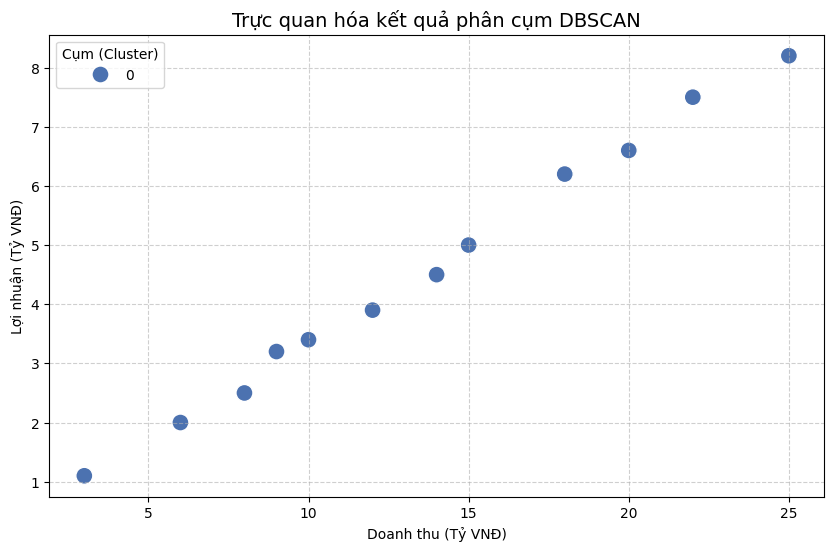

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Trực quan hóa kết quả DBSCAN
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_dbscan, x='Doanh thu (Tỷ VNĐ)', y='Lợi nhuận (Tỷ VNĐ)',
                hue='DBSCAN_Cluster', palette='deep', s=150,
                style='DBSCAN_Cluster', markers=True)

plt.title('Trực quan hóa kết quả phân cụm DBSCAN', fontsize=14)
plt.xlabel('Doanh thu (Tỷ VNĐ)')
plt.ylabel('Lợi nhuận (Tỷ VNĐ)')
plt.legend(title='Cụm (Cluster)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### BÀI 3d: Phân tích và Đặt tên Cụm (Cluster Analysis)

Dựa trên kết quả phân cụm K-Means, chúng ta có thể phân tích đặc điểm của từng nhóm:

1. **Cụm (Cluster) 0:** Các công ty có quy mô trung bình (Mid-tier).
2. **Cụm (Cluster) 1:** Các tập đoàn lớn, doanh thu và lợi nhuận cao (Leading Enterprises).
3. **Cụm (Cluster) 2:** Các công ty nhỏ hoặc mới thành lập (Small/Startups).

In [ ]:
# Tính toán giá trị trung bình của các đặc trưng cho mỗi cụm để hiểu rõ hơn
cluster_analysis = df_clustered.groupby('Cluster')[['Doanh thu (Tỷ VNĐ)', 'Lợi nhuận (Tỷ VNĐ)', 'Chi phí Marketing (Tỷ VNĐ)', 'Số lượng khách hàng']].mean()

print('--- Phân tích đặc trưng trung bình theo từng cụm ---')
display(cluster_analysis)

# Đặt tên cho các cụm
cluster_names = {
    0: 'Doanh nghiệp Vừa',
    1: 'Doanh nghiệp Lớn',
    2: 'Doanh nghiệp Nhỏ/Mới'
}
df_clustered['Tên Nhóm'] = df_clustered['Cluster'].map(cluster_names)

print('\n--- Danh sách công ty kèm phân loại nhóm ---')
display(df_clustered[['Công ty', 'Doanh thu (Tỷ VNĐ)', 'Lợi nhuận (Tỷ VNĐ)', 'Tên Nhóm']])

--- Phân tích đặc trưng trung bình theo từng cụm ---


,Doanh thu (Tỷ VNĐ),Lợi nhuận (Tỷ VNĐ),Chi phí Marketing (Tỷ VNĐ),Số lượng khách hàng
Cluster,,,,
0,12.75,4.200,1.800,925.0
1,21.25,7.125,3.050,1575.0
2,6.50,2.200,0.875,517.5



--- Danh sách công ty kèm phân loại nhóm ---


,Công ty,Doanh thu (Tỷ VNĐ),Lợi nhuận (Tỷ VNĐ),Tên Nhóm
0,1,3,1.1,Doanh nghiệp Nhỏ/Mới
1,2,6,2.0,Doanh nghiệp Nhỏ/Mới
2,3,9,3.2,Doanh nghiệp Nhỏ/Mới
3,4,10,3.4,Doanh nghiệp Vừa
4,5,12,3.9,Doanh nghiệp Vừa
5,6,15,5.0,Doanh nghiệp Vừa
6,7,18,6.2,Doanh nghiệp Lớn
7,8,20,6.6,Doanh nghiệp Lớn
8,9,25,8.2,Doanh nghiệp Lớn
9,10,8,2.5,Doanh nghiệp Nhỏ/Mới


### BÀI 3e: So sánh Silhouette Score (K-Means vs. Hierarchical)

**Silhouette Score** giúp đánh giá chất lượng phân cụm:
- Giá trị gần **1**: Các cụm tách biệt rõ ràng và đặc khít.
- Giá trị gần **0**: Các cụm bị chồng lấn.
- Giá trị gần **-1**: Các mẫu bị gán sai cụm.

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

# 1. Tính Silhouette cho K-Means (đã thực hiện ở Bài 3b)
sil_kmeans = silhouette_score(X_scaled, clusters)

# 2. Thực hiện Hierarchical Clustering với k=3 và tính Silhouette
hierarchical = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clusters_hier = hierarchical.fit_predict(X_scaled)
sil_hier = silhouette_score(X_scaled, clusters_hier)

# 3. Hiển thị kết quả so sánh
print(f'Silhouette Score cho K-Means (k=3): {sil_kmeans:.4f}')
print(f'Silhouette Score cho Hierarchical (k=3): {sil_hier:.4f}')

# Kết luận
if sil_kmeans > sil_hier:
    print('\nKết luận: K-Means cho kết quả phân cụm tốt hơn trên tập dữ liệu này.')
elif sil_hier > sil_kmeans:
    print('\nKết luận: Hierarchical Clustering cho kết quả phân cụm tốt hơn trên tập dữ liệu này.')
else:
    print('\nKết luận: Cả hai phương pháp cho kết quả tương đương.')

Silhouette Score cho K-Means (k=3): 0.4901
Silhouette Score cho Hierarchical (k=3): 0.4997

Kết luận: Hierarchical Clustering cho kết quả phân cụm tốt hơn trên tập dữ liệu này.


### BÀI 4: GIẢM CHIỀU DỮ LIỆU (PRINCIPAL COMPONENT ANALYSIS - PCA)

PCA giúp chúng ta nén 4 đặc trưng ban đầu thành 2 thành phần chính (PC1, PC2) mà vẫn giữ được tối đa lượng thông tin (phương sai) của dữ liệu.

Tỷ lệ phương sai giải thích bởi PC1: 99.73%
Tỷ lệ phương sai giải thích bởi PC2: 0.18%
Tổng cộng: 99.91%


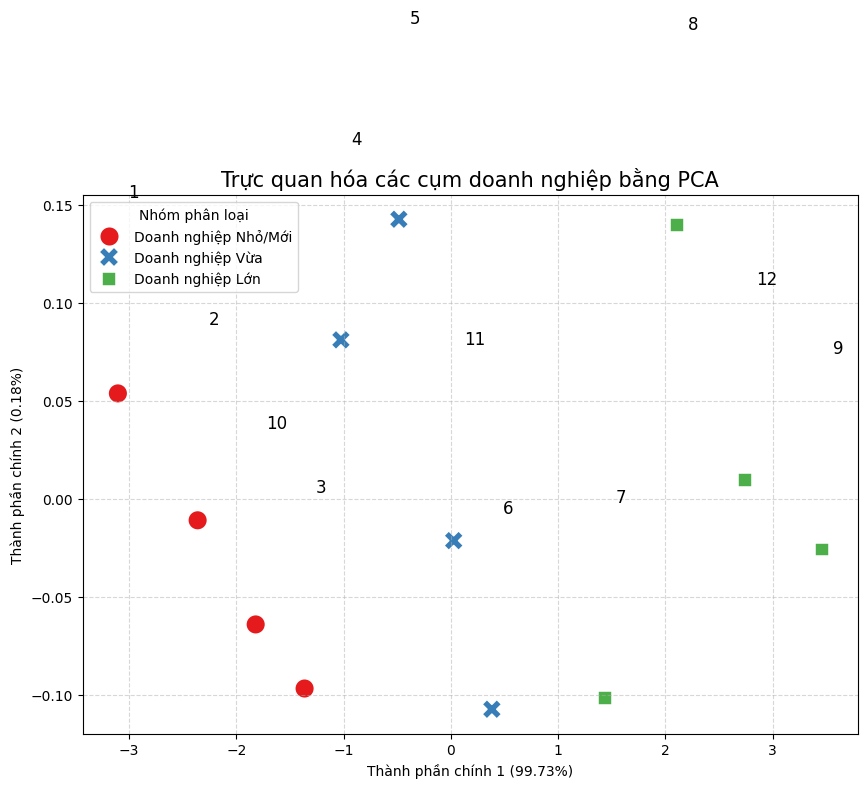

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Đảm bảo df_clustered đã tồn tại (phòng trường hợp người dùng chưa chạy Bài 3d)
if 'df_clustered' not in locals():
    kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    df_clustered = df.copy()
    df_clustered['Cluster'] = clusters
    cluster_names = {0: 'Doanh nghiệp Vừa', 1: 'Doanh nghiệp Lớn', 2: 'Doanh nghiệp Nhỏ/Mới'}
    df_clustered['Tên Nhóm'] = df_clustered['Cluster'].map(cluster_names)

# 1. Khởi tạo PCA để giảm xuống 2 chiều
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

# 2. Tạo DataFrame mới cho kết quả PCA
df_pca = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df_clustered['Tên Nhóm']
df_pca['Công ty'] = df_clustered['Công ty']

# 3. Tính toán tỷ lệ phương sai được giải thích
explained_variance = pca.explained_variance_ratio_
print(f'Tỷ lệ phương sai giải thích bởi PC1: {explained_variance[0]:.2%}')
print(f'Tỷ lệ phương sai giải thích bởi PC2: {explained_variance[1]:.2%}')
print(f'Tổng cộng: {sum(explained_variance):.2%}')

# 4. Trực quan hóa
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', style='Cluster', s=200, palette='Set1')

# Chú thích mã số công ty lên biểu đồ
for i in range(df_pca.shape[0]):
    plt.text(df_pca.PC1[i]+0.1, df_pca.PC2[i]+0.1, str(df_pca['Công ty'][i]), fontsize=12)

plt.title('Trực quan hóa các cụm doanh nghiệp bằng PCA', fontsize=15)
plt.xlabel(f'Thành phần chính 1 ({explained_variance[0]:.2%})')
plt.ylabel(f'Thành phần chính 2 ({explained_variance[1]:.2%})')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Nhóm phân loại')
plt.show()

### BÀI 5: LƯU TRỮ MÔ HÌNH (MODEL DEPLOYMENT PREPARATION)

Trong thực tế, sau khi huấn luyện xong, chúng ta cần lưu lại các mô hình và bộ chuẩn hóa (Scaler) để triển khai trên các hệ thống khác.

In [ ]:
import pickle
import os

# Tạo thư mục lưu trữ nếu chưa có
if not os.path.exists('models'):
    os.makedirs('models')

# 1. Lưu bộ chuẩn hóa dữ liệu
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 2. Lưu các mô hình phân loại nhị phân
for name, model in models.items():
    filename = f'models/{name.replace(" ", "_").lower()}_model.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(model, f)

# 3. Lưu mô hình PCA
with open('models/pca_transformer.pkl', 'wb') as f:
    pickle.dump(pca, f)

print('--- Hoàn tất Bài 5 ---')
print('Các tệp tin đã được lưu trong thư mục "models/":')
print(os.listdir('models/'))

### TỔNG KẾT DỰ ÁN

1. **Bài 1:** Khởi tạo Toy Dataset từ PDF.
2. **Bài 2:** Tiền xử lý & Huấn luyện mô hình phân loại (Binary & Multiclass).
3. **Bài 3:** Phân cụm doanh nghiệp (K-Means, Hierarchical, DBSCAN).
4. **Bài 4:** Giảm chiều dữ liệu PCA và trực quan hóa.
5. **Bài 5:** Lưu trữ mô hình để tái sử dụng.